# Privacy Pipeline — Experiment Notebook

End-to-end workflow:
1. Load config from `experiment.yaml`
2. Load and preprocess dataset → `Dataset`
3. (Optional) Inspect k-NN graph → `GraphDiagnostics`
4. Run epsilon sweep → `ExperimentResults` with typed records
5. Inspect typed results (noise metadata, attack results, per-ε records)
6. Plot privacy–utility tradeoff and Fiedler evolution
7. Deep-dive: clean embedding classification

Change `experiment.yaml` to switch datasets, mechanisms, or epsilons — no code edits needed.

In [1]:
from privacy_pipeline import (
    # Config
    load_config, PrivacyExperiment,
    # Pipeline
    DPLaplacianEigenmaps, EmbeddingResult,
    # Graph
    diagnose_knn_graph, GraphDiagnostics, visualize_knn_graph,
    # Noise
    SpectralGapNoise, SpectralGapMetadata, build_noise_mechanism,
    # Evaluate
    run_classification, run_attack_all_classes,
    display_classification_results,
    ClassifierResult, AttackResult,
    # Features
    Dataset,
    # Results
    ExperimentResults, EpsilonRecord, FiedlerRecord, BaselineRecord,
    # Plots
    plot_privacy_utility_tradeoff, plot_fiedler_evolution,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cfg = load_config('experiment_paderborn.yaml')
print(cfg)

ExperimentConfig(data=DataConfig(file_path='paderborn_features.csv', meta_cols=['file_id', 'experiment', 'fault_size', 'load'], label_col='label', feature_groups=None), graph=GraphConfig(n_neighbors=27, normalized=True), embedding=EmbeddingConfig(n_components=4), noise=NoiseConfig(mechanism='spectral_gap', epsilons=[0.1, 0.25, 0.5, 0.75, 1.0, 2.0], params={'snr_target': 0.525}), evaluation=EvaluationConfig(n_splits=10, random_state=42), output=OutputConfig(results_dir='results_paderborn', figures_dir='figures', save_csv=True, save_figures=True, dpi=300))


In [2]:
# ── Load & preprocess dataset → Dataset ───────────────────────────────────────
experiment = PrivacyExperiment(cfg)
ds = experiment.load_data()          # returns Dataset(X, y, target_names)
print(ds)                            # Dataset(samples=..., features=..., classes=[...])

X_scaled, y, target_names = ds       # NamedTuple: still unpackable as a 3-tuple

Dataset(samples=602579, features=127, classes=['IR', 'Normal', 'OR'])


In [3]:
# ── (Optional) Inspect k-NN graph → GraphDiagnostics ─────────────────────────
from sklearn.neighbors import kneighbors_graph
A = kneighbors_graph(X_scaled, n_neighbors=cfg.graph.n_neighbors,
                     mode='distance', include_self=False, n_jobs=-1)
A = 0.5 * (A + A.T)

diag: GraphDiagnostics = diagnose_knn_graph(A)
print(diag)
print(f"  Connected : {diag.is_connected}")
print(f"  Components: {diag.n_components}")
print(f"  Nodes / Edges: {diag.n_nodes} / {diag.n_edges}")
print(f"  Degree  min={diag.degree_min:.1f}  mean={diag.degree_mean:.1f}  max={diag.degree_max:.1f}")
if not diag.is_connected:
    print(f"  Component sizes: {diag.component_sizes}")

GraphDiagnostics(nodes=602579, edges=14287571, connected, degree=46.5/166.3/2940.5)
  Connected : True
  Components: 1
  Nodes / Edges: 602579 / 14287571
  Degree  min=46.5  mean=166.3  max=2940.5


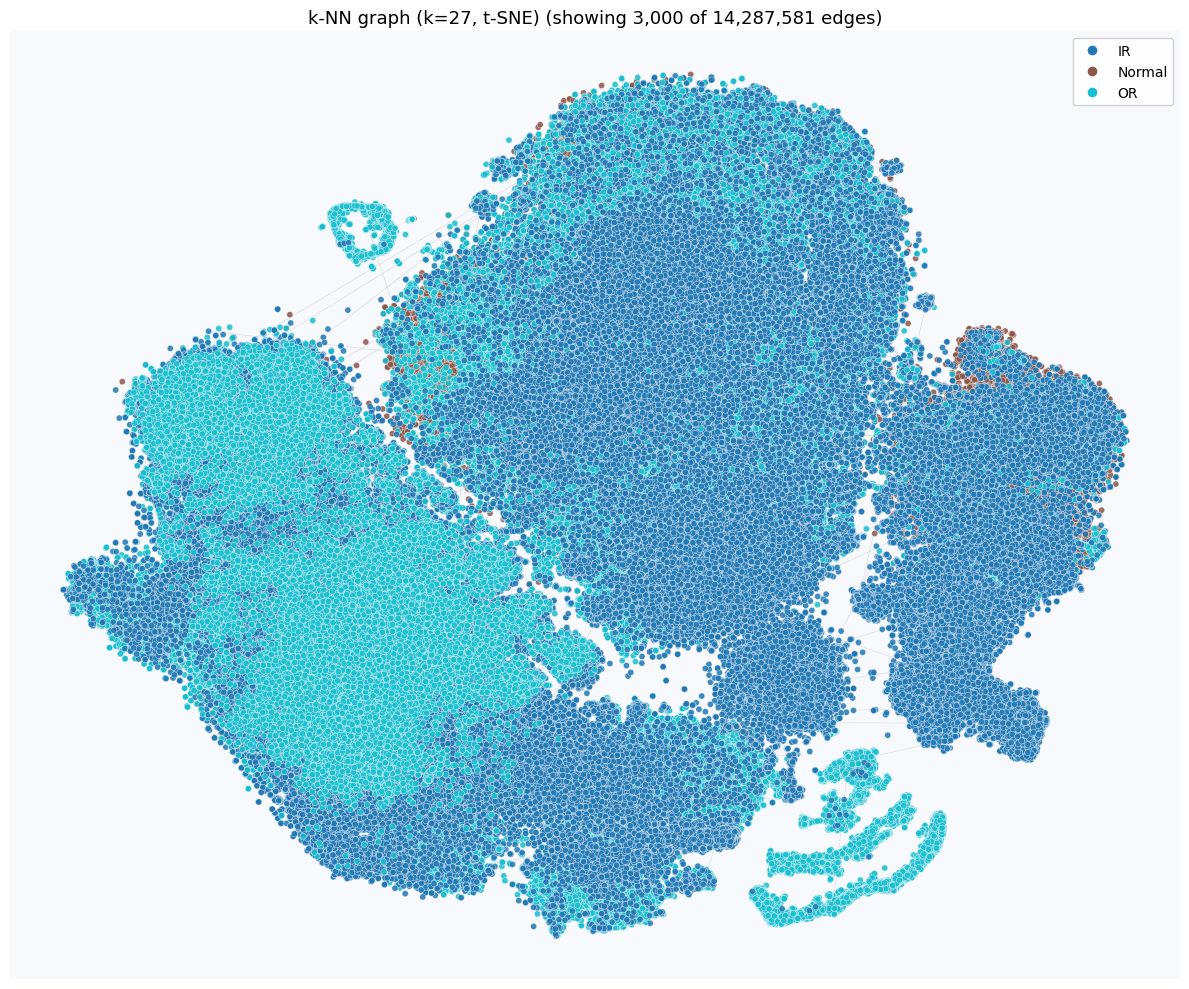

In [4]:
# ── (Optional) Visualize k-NN graph ──────────────────────────────────────────
fig = visualize_knn_graph(X_scaled, y, target_names=list(target_names),
                          n_neighbors=cfg.graph.n_neighbors)
plt.show()

In [ ]:
# ── Run epsilon sweep → ExperimentResults ─────────────────────────────────────
# Sweeps all epsilons from experiment.yaml; saves CSVs + figures/
results: ExperimentResults = experiment.run(X_scaled, y, target_names)
print(results)   # ExperimentResults(epsilons=[...], f1_range=[..., ...])

In [ ]:
# ── Inspect typed results ─────────────────────────────────────────────────────

# EpsilonRecord — one per ε, full attribute access
rec: EpsilonRecord = results.records[-1]   # highest ε (least noise)
print(f"ε={rec.epsilon}  macro_f1={rec.macro_f1:.4f}  adv_auc={rec.adv_auc:.4f}")
print(f"  privacy_gain={rec.privacy_gain:+.4f}  random_baseline={rec.random_baseline:.4f}")
print(f"  fiedler: {rec.fiedler_clean:.4f} → {rec.fiedler_noisy:.4f}  (ratio {rec.fiedler_ratio:.4f})")
print()

# BaselineRecord — unperturbed reference stages
for br in results.baseline_records:
    print(f"{br.stage:<20}  F1={br.macro_f1:.4f}  adv_auc={br.adv_auc:.4f}")
print()

# DataFrame view (lazy property — built on demand)
results.metrics_df

ε=2.0  macro_f1=0.7408  adv_auc=0.7745
  privacy_gain=-0.0377  random_baseline=0.6667
  fiedler: 0.0141 → 0.0136  (ratio 0.9686)

Raw Features          F1=0.8770  adv_auc=0.8715
Clean Embedding       F1=0.7529  adv_auc=0.7759



,epsilon,macro_f1,adv_auc,adv_accuracy,privacy_gain,random_baseline,noise_scale,spectral_gap,noise_to_gap,fiedler_clean,fiedler_noisy,fiedler_ratio
0,0.05,0.3423,0.521967,0.518033,0.148600,0.666667,0.490276,0.008774,55.879814,0.014062,0.002364,0.168112
1,0.10,0.3441,0.540700,0.532500,0.134167,0.666667,0.245138,0.008774,27.939907,0.014062,0.001207,0.085839
2,0.20,0.3441,0.509067,0.507000,0.159667,0.666667,0.122569,0.008774,13.969953,0.014062,0.001112,0.079048
3,0.50,0.3901,0.554167,0.543100,0.123533,0.666667,0.049028,0.008774,5.587981,0.014062,0.000783,0.055710
4,1.00,0.6239,0.728533,0.663200,0.003467,0.666667,0.024514,0.008774,2.793991,0.014062,0.007550,0.536897
5,2.00,0.7408,0.774467,0.704333,-0.037700,0.666667,0.012257,0.008774,1.396995,0.014062,0.013621,0.968633


In [ ]:
# ── Inspect noise metadata for one epsilon ────────────────────────────────────
# Run a single forward pass to see the typed SpectralGapMetadata
mechanism = build_noise_mechanism(
    cfg.noise.mechanism, epsilon=cfg.noise.epsilons[2],  # mid-range ε
    **cfg.noise.params,
)
model = DPLaplacianEigenmaps(
    n_neighbors=cfg.graph.n_neighbors,
    n_components=cfg.embedding.n_components,
    noise_mechanism=mechanism,
    normalized=cfg.graph.normalized,
)
result: EmbeddingResult = model.fit_transform(X_scaled)
print(result)
print()

meta = result.noise_metadata
print(f"Mechanism type : {meta.type}")
print(f"Noise scale    : {meta.scale:.6f}")
print(f"Spectral gap   : {meta.gap:.6f}")
print(f"Noise/gap ratio: {meta.noise_to_gap:.4f}")
print(f"Fiedler clean  : {meta.fiedler_gap_clean:.6f}")
print(f"Fiedler noisy  : {meta.fiedler_gap_noisy:.6f}")
print(f"Fiedler ratio  : {meta.fiedler_gap_ratio:.4f}")

In [ ]:
# ── Inspect AttackResult ──────────────────────────────────────────────────────
avg_atk, per_class_atk = run_attack_all_classes(
    result.embedding_noisy, y, list(target_names),
    cv=cfg.evaluation.n_splits, random_state=cfg.evaluation.random_state,
)
print("Class-averaged attack result:")
print(avg_atk)
print(f"  adv_auc        = {avg_atk.adv_auc:.4f}")
print(f"  random_baseline= {avg_atk.random_baseline:.4f}")
print(f"  privacy_gain   = {avg_atk.privacy_gain:+.4f}")
print(f"  is_private     = {avg_atk.is_private}")
print()
display(avg_atk.to_frame())
print()
print("Per-class:")
for cls, atk in zip(target_names, per_class_atk):
    print(f"  {cls}: {atk}")

In [ ]:
# ── Privacy–utility tradeoff ──────────────────────────────────────────────────
fig = plot_privacy_utility_tradeoff(
    results.records,                        # list[EpsilonRecord]
    baseline_records=results.baseline_records,  # list[BaselineRecord]
)
plt.show()

In [ ]:
# ── Fiedler gap evolution ─────────────────────────────────────────────────────
fig = plot_fiedler_evolution(results.fiedler_records)  # list[FiedlerRecord]
plt.show()

In [ ]:
# ── Deep-dive: classification on clean embedding ──────────────────────────────
clean_model = DPLaplacianEigenmaps(
    n_neighbors=cfg.graph.n_neighbors,
    n_components=cfg.embedding.n_components,
    normalized=cfg.graph.normalized,
)
clean: EmbeddingResult = clean_model.fit_transform(X_scaled)
print(clean)

clf_res: dict[str, ClassifierResult] = run_classification(
    clean.embedding_clean, y, target_names,   # attribute access, not string key
    cv=cfg.evaluation.n_splits,
)
print(f"\nRandom Forest  macro_f1={clf_res['Random Forest'].macro_f1:.4f}")
print(f"SVM            macro_f1={clf_res['SVM'].macro_f1:.4f}")
print()
display_classification_results(clf_res)

## Three-Way Pipeline Comparison

Compare noise injected at three different stages:
- **Laplacian-space** — perturb L before eigendecomposition (existing)
- **Feature-space** — perturb raw features X before graph construction
- **Embedding-space** — perturb eigenvectors V after Laplacian Eigenmaps

All pipelines share the same ε sweep, snr_target, classifiers, and inference-attack mechanism.

In [ ]:
from privacy_pipeline import (
    ComparisonExperiment, ComparisonResults, ComparisonRecord, PipelineMetrics,
    plot_pipeline_comparison, plot_comparison_tradeoff,
    FeatureSpaceNoisePipeline, EmbeddingSpaceNoisePipeline,
)

# ComparisonExperiment reads the same experiment.yaml
cmp_exp = ComparisonExperiment(cfg)
print(cmp_exp.cfg.noise.epsilons)

In [ ]:
# ── Run three-way comparison sweep ────────────────────────────────────────────
# Uses X_scaled, y, target_names already loaded above
cmp_results: ComparisonResults = cmp_exp.run(X_scaled, y, target_names)
print(cmp_results)

In [ ]:
# ── Inspect a single ComparisonRecord ─────────────────────────────────────────
rec: ComparisonRecord = cmp_results.records[-1]   # highest ε (least noise)
print(f"ε = {rec.epsilon}")
print(f"  Laplacian  F1={rec.laplacian.macro_f1:.4f}  AUC={rec.laplacian.adv_auc:.4f}  priv_gain={rec.laplacian.privacy_gain:+.4f}")
print(f"  Feature    F1={rec.feature.macro_f1:.4f}  AUC={rec.feature.adv_auc:.4f}  priv_gain={rec.feature.privacy_gain:+.4f}")
print(f"  Embedding  F1={rec.embedding.macro_f1:.4f}  AUC={rec.embedding.adv_auc:.4f}  priv_gain={rec.embedding.privacy_gain:+.4f}")

In [ ]:
# ── Long-format DataFrame (one row per ε × pipeline) ──────────────────────────
cmp_results.long_df

In [ ]:
# ── Wide-format DataFrame (one row per ε) ──────────────────────────────────────
cmp_results.wide_df

In [ ]:
# ── F1 and AUC line plots across ε ────────────────────────────────────────────
fig = plot_pipeline_comparison(cmp_results)
plt.show()

In [ ]:
# ── Privacy–utility scatter: all three trajectories ───────────────────────────
fig = plot_comparison_tradeoff(cmp_results)
plt.show()